In [1]:
from pathlib import Path
import json
from dataclasses import asdict
from itertools import product

from rabl.machine_learning.tuner import GridSearchConfig, TrialResult, count_grid_combinations, run_grid_search, test_best_model
from rabl.machine_learning.lstm_pipeline import (
    build_datasets,
    train_with_fallback,
    cleanup_cuda,
    save_forecast_profiles_pdf,
)

In [5]:
lookback_datasets = {
    12: Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k12_minmax_train0.70_val0.15_test0.15.h5"),
    #8:  Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k8_minmax_train0.70_val0.15_test0.15.h5"),
    #4:  Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0002_k4_minmax_train0.70_val0.15_test0.15.h5"),
}

for lb, p in lookback_datasets.items():
    print(f"lookback={lb} exists={p.exists()} path={p}")

lookback=12 exists=True path=..\outputs\datasets\scaled_split\lstm_merged_batches_0001-0002_k12_minmax_train0.70_val0.15_test0.15.h5


In [7]:
out_dir = Path("../outputs/ml_results/tuning_single_model")
out_dir.mkdir(parents=True, exist_ok=True)

config = GridSearchConfig(
    lookback_datasets=lookback_datasets,
    learning_rates=[1e-4, 1e-3],
    batch_sizes=[128, 256],
    n_lstm_values=[1, 2, 3],
    hidden_lstm_values=[128, 256, 384],
    hidden_fc_values=[256, 384],
    n_fc=1,
    epochs=50,
    seed=123,
    out_dir=out_dir,
    prefer_gpu=True,
    verbose=0,
    lstm_dropout=0.3,
    preload_train_to_device=True,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-6,
    restore_best_weights=True,
    step_lr_step_size=30,
    step_lr_gamma=0.5,
)

print("out_dir:", config.out_dir)
print("Total trials:", count_grid_combinations(config))

out_dir: ..\outputs\ml_results\tuning_test2
Total trials: 1


Total combinations: 1
[1/1] lookback=12, lr=0.0001, batch_size=256, n_lstm=1, hidden_lstm=256, hidden_fc=256
Using GPU: NVIDIA GeForce RTX 4060 Ti

Deterministic seed set to: 123
LSTMRegressor architecture:
  Input features: 14
  LSTM layers (1): hidden_size=256, dropout=0.3
  FC layers (1): [256]
  Output targets: 13



C:\Users\Logan\anaconda3\envs\pymola\Lib\site-packages\torch\nn\modules\rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
Preloading train batches: 10943batch [00:29, 377.28batch/s]


Preloaded 10943 training batches to cuda:0 in 29.01s.


Train 1/50: 100%|██████████████████████████████████████████| 10943/10943 [00:30<00:00, 354.29batch/s, loss=0.000009493]
Val 1/50: 2345batch [00:07, 300.45batch/s]


Epoch 1/50 - loss: 0.000941142 - val_loss: 0.000019374 - lr: 1.000e-04 - data_wait: 0.14s - h2d: 0.00s - compute: 25.90s - val_time: 7.81s - preloaded: True - preload_time: 29.01s - max_cuda_mem: 2207.99 MB


...

Epoch 31/50 - loss: 0.000000078 - val_loss: 0.000002984 - lr: 5.000e-05 - data_wait: 0.14s - h2d: 0.00s - compute: 25.35s - val_time: 7.98s - preloaded: True - preload_time: 29.01s - max_cuda_mem: 2207.99 MB
Early stopping check: 8/10 epochs without validation improvement.


Train 32/50: 100%|█████████████████████████████████████████| 10943/10943 [00:30<00:00, 361.11batch/s, loss=0.000000595]
Val 32/50: 2345batch [00:07, 298.00batch/s]


Epoch 32/50 - loss: 0.000000075 - val_loss: 0.000001931 - lr: 5.000e-05 - data_wait: 0.14s - h2d: 0.00s - compute: 25.31s - val_time: 7.87s - preloaded: True - preload_time: 29.01s - max_cuda_mem: 2207.99 MB
Early stopping check: 9/10 epochs without validation improvement.


Train 33/50: 100%|█████████████████████████████████████████| 10943/10943 [00:30<00:00, 358.77batch/s, loss=0.000000258]
Val 33/50: 2345batch [00:08, 291.89batch/s]


Epoch 33/50 - loss: 0.000000069 - val_loss: 0.000001128 - lr: 5.000e-05 - data_wait: 0.14s - h2d: 0.00s - compute: 25.52s - val_time: 8.04s - preloaded: True - preload_time: 29.01s - max_cuda_mem: 2207.99 MB
Early stopping check: 10/10 epochs without validation improvement.
Early stopping triggered at epoch 33; best validation loss was 0.000000673 at epoch 23.
Restored best model weights from epoch 23.
Saved training curves to ..\outputs\ml_results\tuning_test2\trial_0001_lb12_lr0.0001_bs256_nl1_hl256_hf256\lstm_train_val_curve.png
Saved learning-rate curve to ..\outputs\ml_results\tuning_test2\trial_0001_lb12_lr0.0001_bs256_nl1_hl256_hf256\lstm_lr_curve.png

Timing summary (cumulative):
  preload_time: 29.01s
  train_data_wait_time: 4.59s
  train_h2d_time: 0.05s
  train_compute_time: 850.85s
  train_epoch_time_total: 855.48s
  val_time_total: 261.88s
  estimated_total_time: 1146.37s

Best trial:
{
  "lookback": 12,
  "dataset_path": "..\\outputs\\datasets\\scaled_split\\lstm_merged_ba

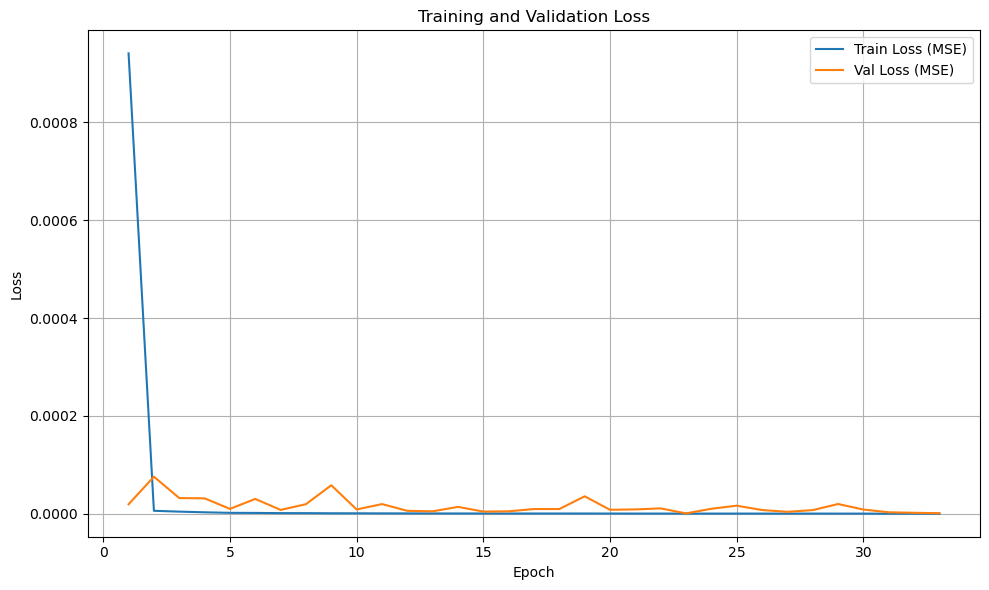

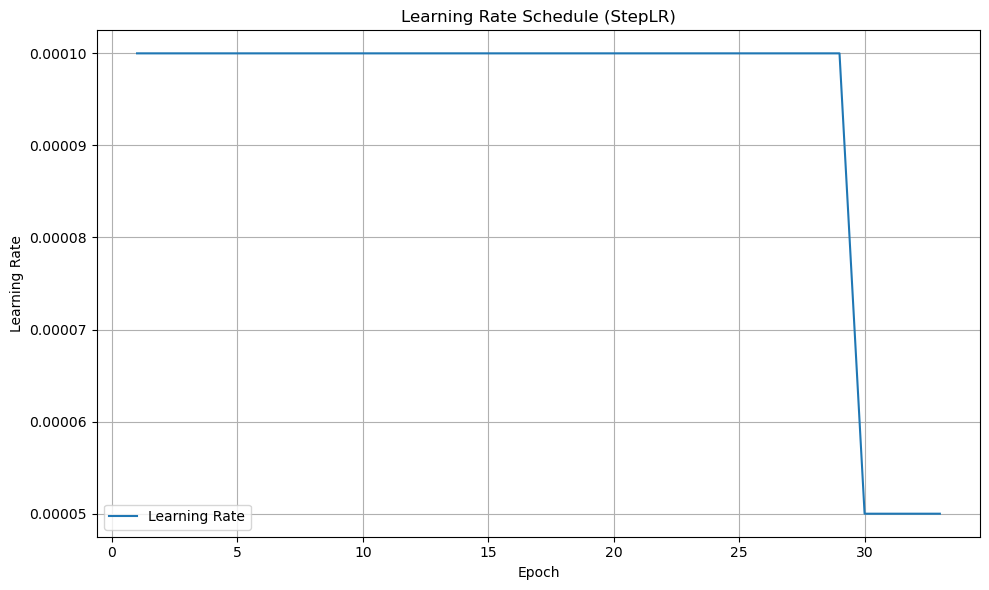

In [9]:
results, best = run_grid_search(config)
print("Best trial:", best)

In [10]:
test_metrics = test_best_model(config, best)
print("Test timing metrics:", test_metrics)

C:\Users\Logan\anaconda3\envs\pymola\Lib\site-packages\torch\nn\modules\rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


LSTMRegressor architecture:
  Input features: 14
  LSTM layers (1): hidden_size=256, dropout=0.3
  FC layers (1): [256]
  Output targets: 13



Forecast profiles: 300profile [03:34,  1.40profile/s, mae_avg=1.726782e+03]


Testing timing summary: total_fetch: 0.0002s -  total_test: 210.5425s -  avg_fetch_profile: 0.0000s -  avg_inference_profile: 0.7018s -  save_time: 0.1603s

Saved best-model test outputs to: ..\outputs\ml_results\tuning_test2\trial_0001_lb12_lr0.0001_bs256_nl1_hl256_hf256\best_model_test
Test timing metrics: {'avg_fetch_profile_s': 6.003313076992829e-07, 'avg_inference_profile_s': 0.7018076030001975, 'total_fetch_s': 0.0001800993923097849, 'total_test_s': 210.54246099945158, 'save_time_s': 0.16031750000547618}


In [4]:
save_forecast_profiles_pdf(
    forecast_h5_path=Path("../outputs/ml_results/tuning_test2/trial_0001_lb12_lr0.0001_bs256_nl1_hl256_hf256/best_model_test/rolling_forecasts.h5"),
    output_pdf_path=Path("../outputs/ml_results/tuning_test2/trial_0001_lb12_lr0.0001_bs256_nl1_hl256_hf256/best_model_test/rolling_forecasts.pdf"),
)

Plotted 10/300
Plotted 20/300
Plotted 30/300
Plotted 40/300
Plotted 50/300
Plotted 60/300
Plotted 70/300
Plotted 80/300
Plotted 90/300
Plotted 100/300
Plotted 110/300
Plotted 120/300
Plotted 130/300
Plotted 140/300
Plotted 150/300
Plotted 160/300
Plotted 170/300
Plotted 180/300
Plotted 190/300
Plotted 200/300
Plotted 210/300
Plotted 220/300
Plotted 230/300
Plotted 240/300
Plotted 250/300
Plotted 260/300
Plotted 270/300
Plotted 280/300
Plotted 290/300
Plotted 300/300
Saved forecast PDF to: ..\outputs\ml_results\tuning_test2\trial_0001_lb12_lr0.0001_bs256_nl1_hl256_hf256\best_model_test\rolling_forecasts.pdf
